Detects spots pairs in confocal `.msr` RNA and DNA FISH images

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
from itertools import product
from scipy.optimize import linear_sum_assignment

In [2]:
# find pairs in DNA chanels
def detect_spot_pairs(path, out, ch, z_name, y_name, x_name,voxel_size=(1, 1, 1)):
    df = pd.read_csv(path)
    df['img'] = df['img'].apply(lambda x: x.rsplit('_', 1)[0])
    
    result = defaultdict(list)
    voxel_size = np.array(voxel_size)
    
    # group the DataFrame by 'img' 
    grouped = df.groupby(['img'])
    
    for img, group_df in grouped:
        spot_coords_ch1 = group_df.loc[group_df['channel'] == ch[0], [z_name1, y_name1, x_name1]].values
        spot_coords_ch2 = group_df.loc[group_df['channel'] == ch[1], [z_name1, y_name1, x_name1]].values
        distances = np.zeros((len(spot_coords_ch1), len(spot_coords_ch2)))
        

        for (i1,c1), (i2, c2) in product(enumerate(spot_coords_ch1), enumerate(spot_coords_ch2)):
            distances[i1, i2] = np.linalg.norm((c1 - c2)*voxel_size) # np.sqrt(np.sum((c1 - c2)**2))
            

        row_ind, col_ind = linear_sum_assignment(distances)
        
        for ri, ci in zip(row_ind, col_ind):
            result['img'].append(img)
            result['distance_um'].append(distances[ri,ci])
            
            for dim_i, dim in enumerate('zyx'):
                result[f'{dim}_1'].append(spot_coords_ch1[ri][dim_i])
                result[f'{dim}_2'].append(spot_coords_ch2[ci][dim_i])

    result_df = pd.DataFrame(result)
    
    # add acquisition info and reshape
    to_drop = ['c','t']
    df = df.drop(columns=[col for col in to_drop if col in df.columns])
    right = ["img","x","y","z"] 
    left1 =  ["img","x_1","y_1","z_1"] 
    left2 = ["img","x_2","y_2","z_2"] 
    
    result_df = result_df.merge(df, left_on=left1, right_on=right ,how='left')
    result_df = result_df.merge(df, left_on=left2, right_on=right ,how='left',suffixes=('.1', '.2'))
    
    
    result_df = result_df.T.drop_duplicates().T
    
    # save to csv
    result_df.to_csv(out, index=False)
    
    
# detect closes RNA to promoter
import pandas as pd
import numpy as np
from collections import defaultdict

def detect_DNA_RNA_spot_pairs(path_spots1, path_spots2, out, out2, ch_p, z_name1, y_name1, x_name1, z_name2, y_name2, x_name2):
    # Read files
    df1 = pd.read_csv(path_spots1)
    df2 = pd.read_csv(path_spots2)

    # Filter for overlaping part of image
    df2 = df2[(df2[x_name2] >= np.min(df1[x_name1])) & (df2[x_name2] <= np.max(df1[x_name1])) &\
        (df2[y_name2] >= np.min(df1[y_name1])) & (df2[y_name2] <= np.max(df1[y_name1]))]

    df1 = df1[(df1[x_name1] >= np.min(df2[x_name2])) & (df1[x_name1] <= np.max(df2[x_name2])) &\
        (df1[y_name1] >= np.min(df2[y_name2])) & (df1[y_name1] <= np.max(df2[y_name2]))]

    # Get coordinates to match
    spot_coords_ch1 = df1.loc[df1['channel'] == ch_p, [z_name1, y_name1, x_name1]].values
    spot_coords_ch2 = df2[[z_name2, y_name2, x_name2]].values

    # Initialize result dictionary
    result = defaultdict(list)
    
    # Store distances and corresponding indices
    all_distances = []
    for i1, c1 in enumerate(spot_coords_ch1):
        # Calculate distances from spot c1 to all spots in spot_coords_ch2
        distances = np.linalg.norm(spot_coords_ch2 - c1, axis=1)
        for i2, dist in enumerate(distances):
            all_distances.append((dist, i1, i2))
    
    # Sort all distances by the first element (the distance)
    all_distances.sort(key=lambda x: x[0])
    
    assigned_spots = set()
    assigned_df1_indices = set()

    # Assign the closest non-duplicate spots
    for dist, i1, i2 in all_distances:
        if i1 not in assigned_df1_indices and i2 not in assigned_spots:
            assigned_spots.add(i2)
            assigned_df1_indices.add(i1)

            result['distance_um'].append(dist)
            for dim_i, dim in enumerate('zyx'):
                result[f'{dim}_1'].append(spot_coords_ch1[i1][dim_i])
                result[f'{dim}_2'].append(spot_coords_ch2[i2][dim_i])

    # Convert results to DataFrame
    result_df = pd.DataFrame(result)
    
    # add acquisition info to df and reshape
    df1 = df1.drop(columns=['c','t'])
    right1 = [z_name1, y_name1, x_name1] 
    right2 = [z_name2, y_name2, x_name2] 
    left1 =  ["z_1","y_1","x_1"] 
    left2 = ["z_2","y_2","x_2"] 

    result_df = result_df.merge(df1, left_on=left1, right_on=right1 ,how='left')
    result_df = result_df.merge(df2, left_on=left2, right_on=right2 ,how='left',suffixes=('.1', '.2'))

    result_df = result_df.T.drop_duplicates().T

    result_df.to_csv(out2, index=False)

In [3]:
# add distance to closest RNA, to DNA pairs
def add_RNA_to_DNA(df1,df2,out):

    df1 = pd.read_csv(out_distances1) #dna dist
    df2 = pd.read_csv(out_distances2) #rna dist
    
    df2 = df2[['z_1','y_1','x_1','intensity.2','distance_um','z_2','y_2','x_2']] # get the DNA spot coords to join on + 
                                                                                   # intensity and distance to RNA spot
    df2 = df2.rename(columns={'distance_um': 'distance_RNA_um',
                              'intensity.2': 'intensity_RNA',
                              'z_2': 'z_RNA',
                              'y_2': 'y_RNA',
                              'x_2': 'x_RNA'})
    
    left = ['z_1','y_1','x_1']
    right =  ['z_1','y_1','x_1']
    df = df1.merge(df2, left_on=left, right_on=right ,how='left',suffixes=('', '.RNA'))

#     df = df.drop(columns=['z_1.RNA', 'y_1.RNA', 'x_1.RNA']) 
    
    df.to_csv(out, index=False)

# Match spots and calculate distances

In [7]:
in_path1 = "/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/" #upper level experiment folder
in_path2 = "/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240725_RNAFISH/"
channels = [0,1] # which channels to match
ch_p = 0 # whihc is the promoter channel
z_name1, y_name1, x_name1 = "z_global_um", "y_global_um", "x_global_um"# names of global coords
z_name2, y_name2, x_name2 = "z_aligned_um", "y_aligned_um", "x_aligned_um"# names of aligned global coords


# voxel_size=(250, 150, 150) #sizes of zyx [nm]
rel_spot_path1 = "/detections_confocal/merge_global_coords.csv" #spot file path relative to in_path
rel_spot_path2 = "/detections_confocal/merge_global_coords_aligned.csv" #spot file path relative to in_path
out = "/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/distances_confocal2.csv"

In [8]:
path_spots1 = f"{in_path1}/{rel_spot_path1}" #DNA
path_spots2 = f"{in_path2}/{rel_spot_path2}" #RNA

out_distances1 = f"{in_path1}/distances_confocal.csv"
out_distances2 = f"{in_path2}/distances_confocal.csv"


detect_spot_pairs(path_spots1,out_distances1,channels,z_name1, y_name1, x_name1)

detect_DNA_RNA_spot_pairs(path_spots1, path_spots2, out_distances1, out_distances2, 
                          ch_p,z_name1, y_name1, x_name1,z_name2, y_name2, x_name2)

add_RNA_to_DNA(out_distances1,out_distances2,out) 

# Visualize aligned detections and matches

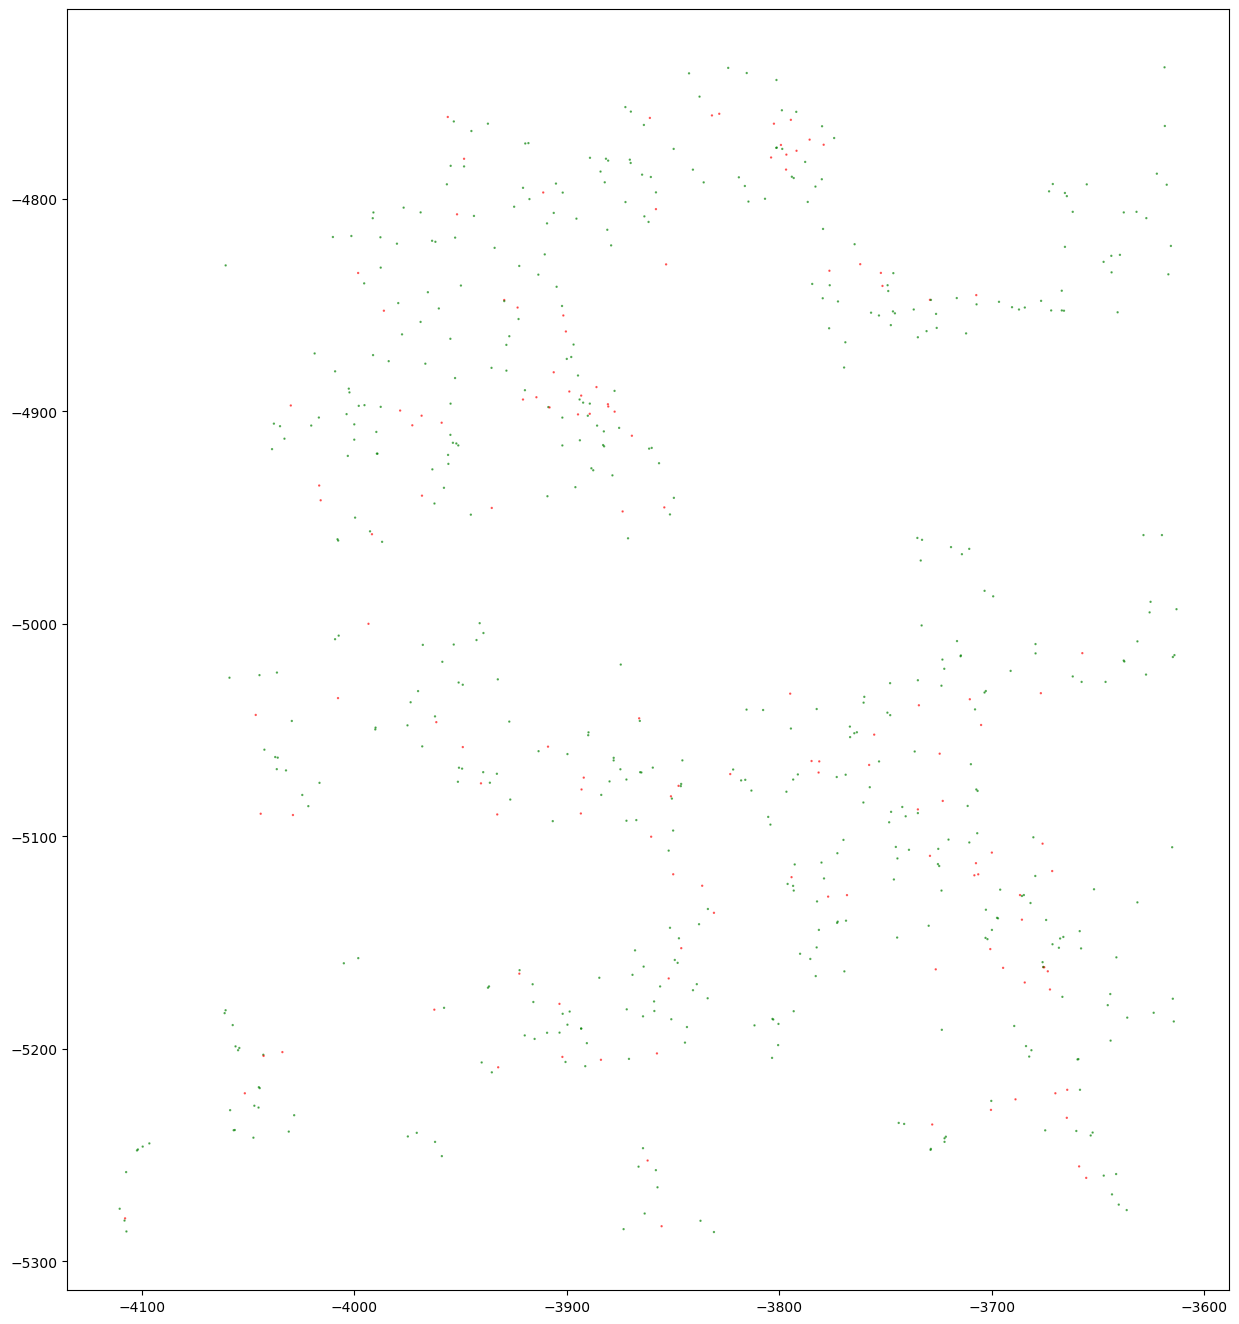

In [10]:
spots = pd.read_csv(out)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 20)) 
colors = ['red' if a <= 5 else 'green' for a in spots['distance_RNA_um']]
plt.scatter(spots['x_1'], spots['y_1'], s=0.5, c=colors,alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')

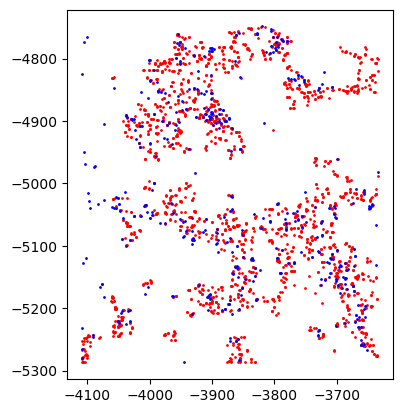

In [11]:
df1 = pd.read_csv(path_spots1) #dna dist
df2 = pd.read_csv(path_spots2) #rna dist

df2 = df2[(df2[x_name2] >= np.min(df1[x_name1])) & (df2[x_name2] <= np.max(df1[x_name1])) &\
        (df2[y_name2] >= np.min(df1[y_name1])) & (df2[y_name2] <= np.max(df1[y_name1]))]

df1 = df1[(df1[x_name1] >= np.min(df2[x_name2])) & (df1[x_name1] <= np.max(df2[x_name2])) &\
        (df1[y_name1] >= np.min(df2[y_name2])) & (df1[y_name1] <= np.max(df2[y_name2]))]

plt.scatter(df1[x_name1],df1[y_name1],c="red",s=1)
plt.scatter(df2[x_name2],df2[y_name2],c="blue",s=1)
plt.gca().set_aspect('equal', adjustable='box')

### Matches

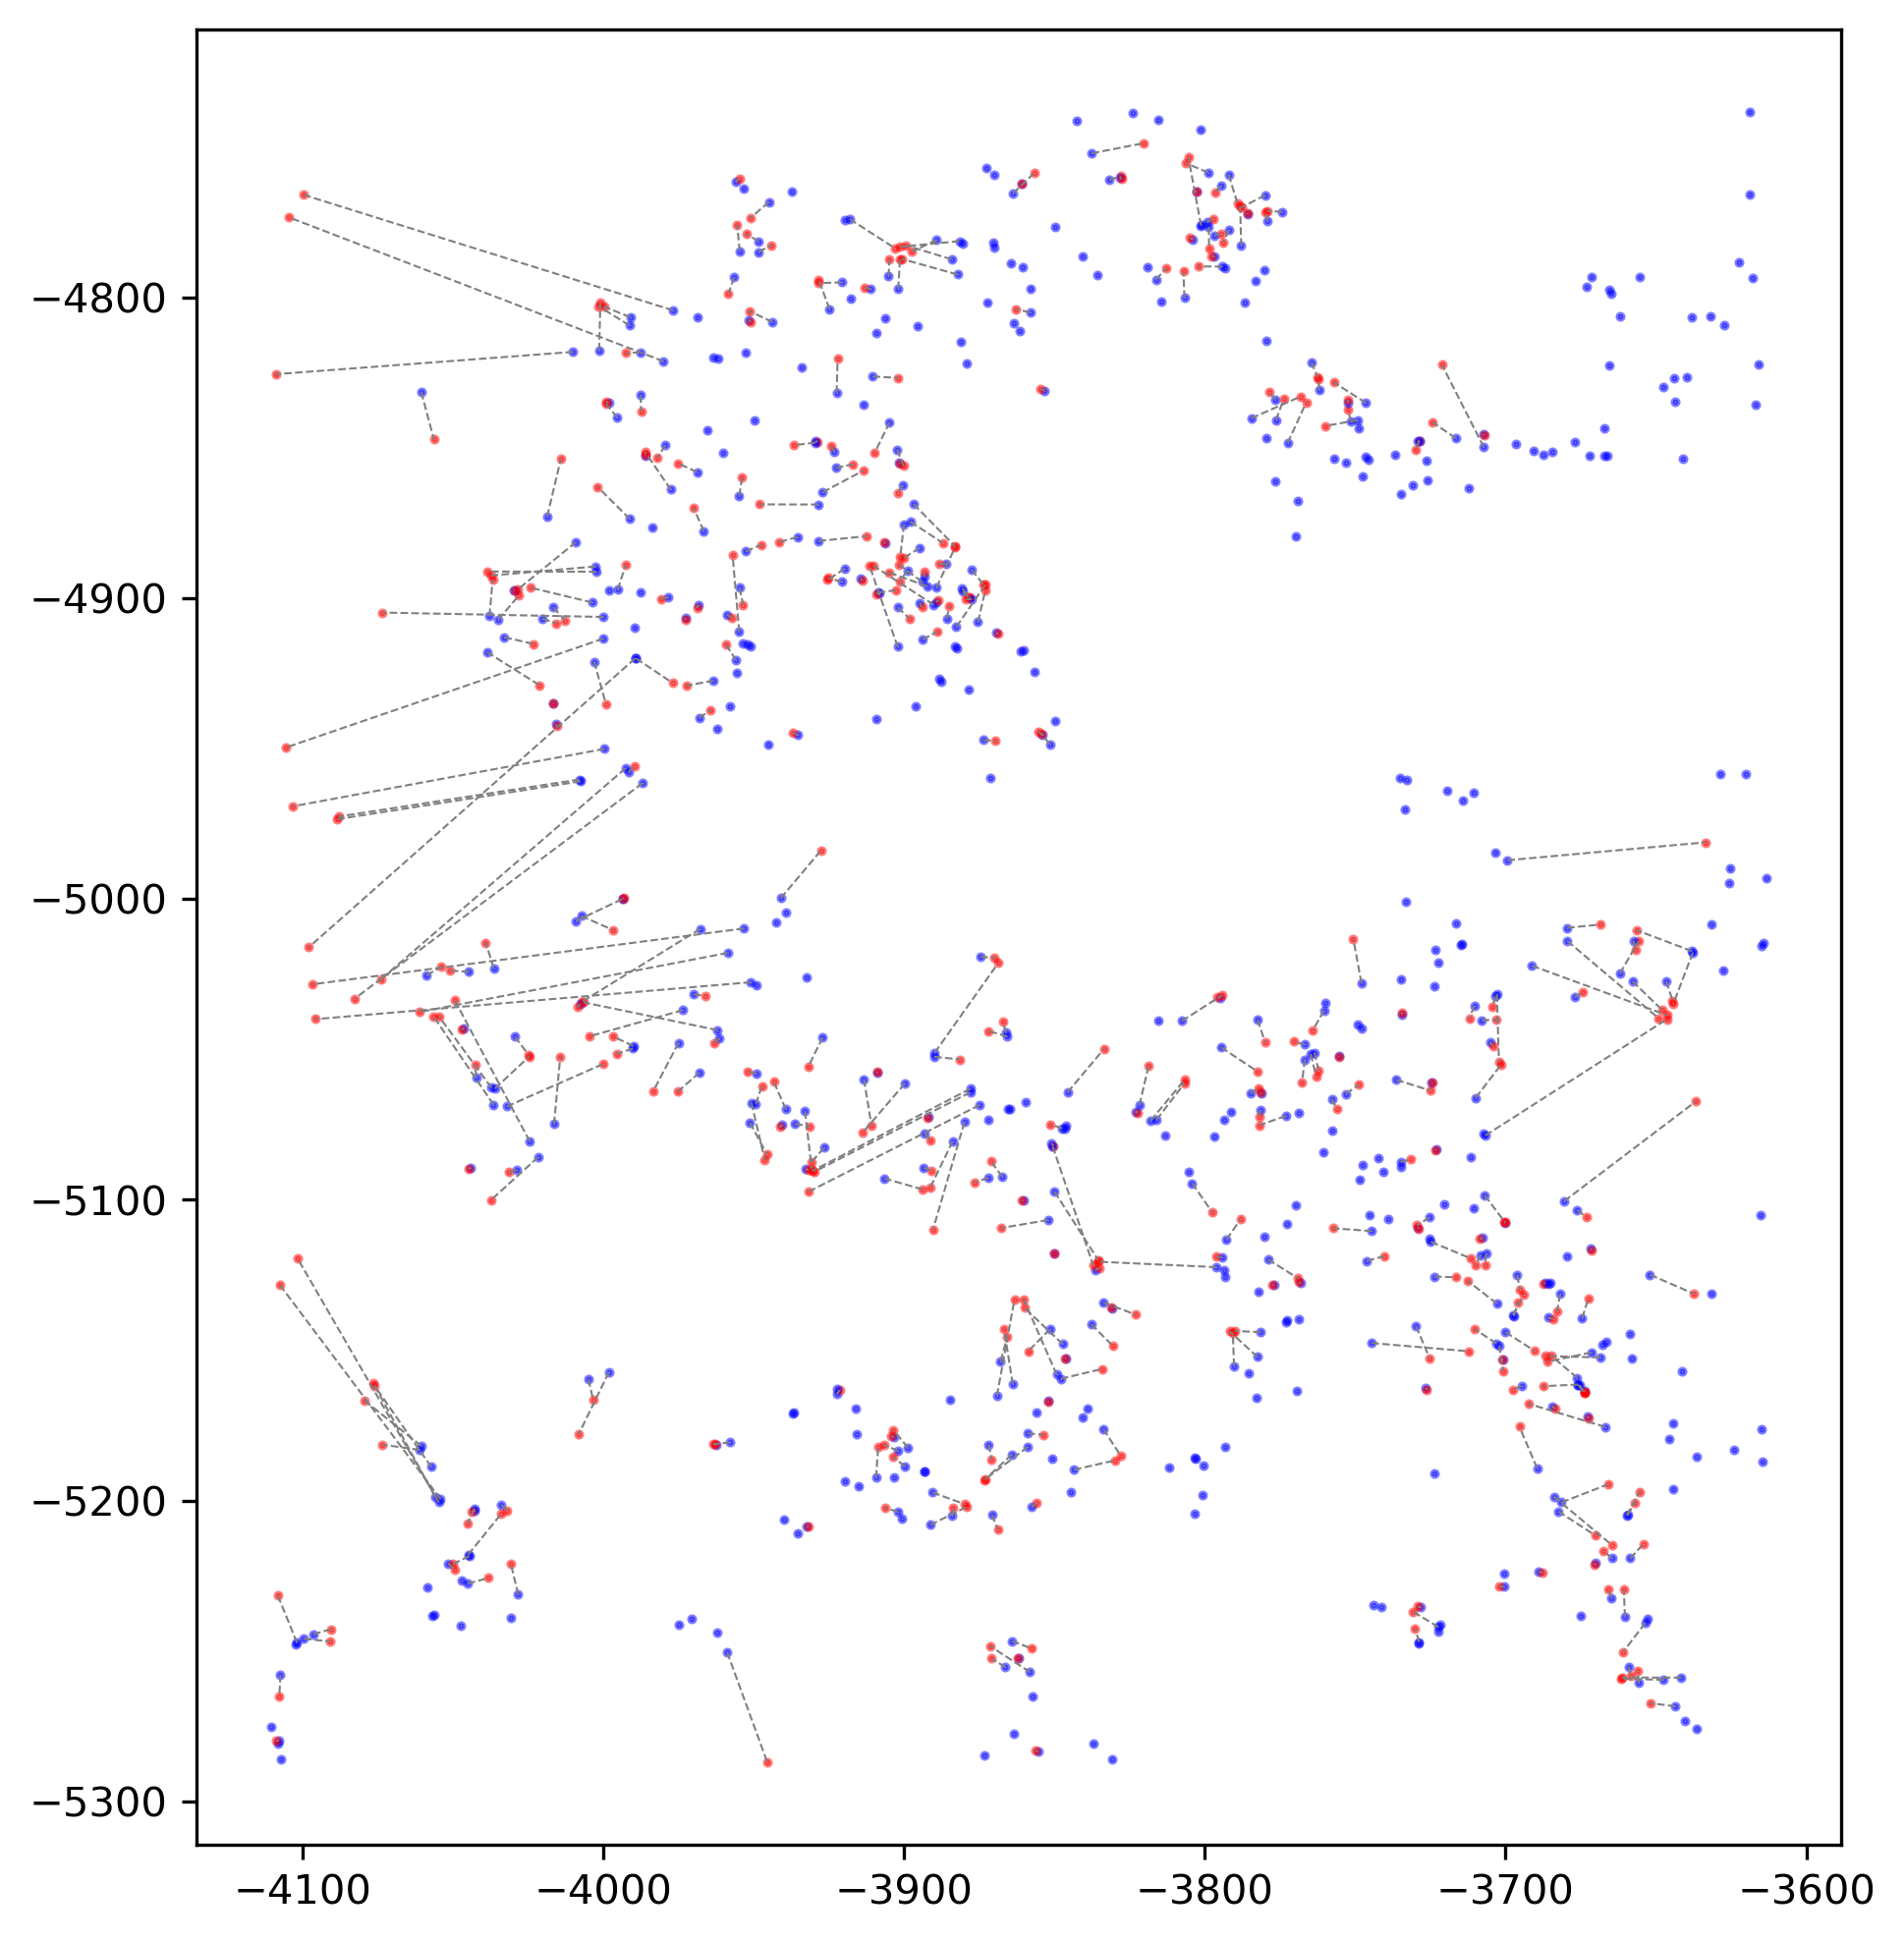

In [12]:
spots = pd.read_csv(out)
spots1 = spots

import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(10, 8), dpi=300)

# Loop through each row in the DataFrame
for _, row in spots1.iterrows():
    # Extract x and y coordinates
    x_1, y_1, x_2, y_2 = row['x_1'], row['y_1'], row['x_RNA'], row['y_RNA']
    
    # Scatter points with different colors
    plt.scatter(x_1, y_1, color='blue',s=2,alpha=0.5)
    plt.scatter(x_2, y_2, color='red',s=2,alpha=0.5)
    
    # Connect the points with a line
    plt.plot([x_1, x_2], [y_1, y_2], color='gray', linestyle='--',linewidth=0.5)


# Show the plot
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig("/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/matches.png",dpi=400)
plt.show()


In [155]:
df1 = pd.read_csv(out_distances1) #dna dist
df2 = pd.read_csv(out_distances2) #rna dist


df2 = df2[['z_1','y_1','x_1','intensity.2','distance_um','z_2','y_2','x_2']] # get the DNA spot coords to join on + 
                                                           # intensity and distance to RNA spot
df2 = df2.rename(columns={'distance_um': 'distance_RNA_um',
                          'intensity.2': 'intensity_RNA',
                          'z_2': 'z_RNA',
                          'y_2': 'y_RNA',
                          'x_2': 'x_RNA'})

left = ['z_1','y_1','x_1']
right =  ['z_1','y_1','x_1']
df = df1.merge(df2, left_on=left, right_on=right ,how='left',suffixes=('', '.RNA'))

#     df = df.drop(columns=['z_1.RNA', 'y_1.RNA', 'x_1.RNA']) 

df.to_csv(out, index=False)